**EXPERIMENT 5 — Ridge, Lasso & Elastic Net**

Step 1 — Imports + Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("placement_predict_50k Dataset.csv")

print(df.shape)
df.head()

(50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


Step 2 — Select features and target

In [2]:
FEATURES = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

X = df[FEATURES].copy()
y = df["PlacementStatus"].copy()

X = X.fillna(X.median())

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 12)
y shape: (50000,)


Step 3 — Train/Validation split + Scaling

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (40000, 12)
Validation: (10000, 12)


Step 4 — Create the compare_regularisation() function

In [4]:
def compare_regularisation(
    X_train,
    y_train,
    X_val,
    y_val,
    C_values
):
    results = []

    for C in C_values:

        # Lasso = L1
        lasso = LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=C,
            max_iter=1000
        )

        # Ridge = L2
        ridge = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            C=C,
            max_iter=1000
        )

        # Elastic Net = L1 + L2
        elastic = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            C=C,
            max_iter=2000
        )

        lasso.fit(X_train, y_train)
        ridge.fit(X_train, y_train)
        elastic.fit(X_train, y_train)

        lasso_pred = lasso.predict(X_val)
        ridge_pred = ridge.predict(X_val)
        elastic_pred = elastic.predict(X_val)

        results.append({
            "C": C,

            "Lasso_val_acc":
                accuracy_score(y_val, lasso_pred),

            "Ridge_val_acc":
                accuracy_score(y_val, ridge_pred),

            "ElasticNet_val_acc":
                accuracy_score(y_val, elastic_pred),

            "Lasso_nonzero":
                np.count_nonzero(lasso.coef_),

            "Ridge_nonzero":
                np.count_nonzero(ridge.coef_),

            "ElasticNet_nonzero":
                np.count_nonzero(elastic.coef_)
        })

    return pd.DataFrame(results)

Step 5 — Choose C values

In [5]:
C_values = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

results = compare_regularisation(
    X_train,
    y_train,
    X_val,
    y_val,
    C_values
)

results

,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero,ElasticNet_nonzero
0,0.001,0.8921,0.8892,0.8897,7,12,9
1,0.010,0.8929,0.8915,0.8926,11,12,12
2,0.100,0.8929,0.8923,0.8922,12,12,12
3,1.000,0.8919,0.8920,0.8919,12,12,12
4,10.000,0.8920,0.8920,0.8920,12,12,12
5,100.000,0.8920,0.8920,0.8920,12,12,12


Step 6 — Plot validation accuracy vs C

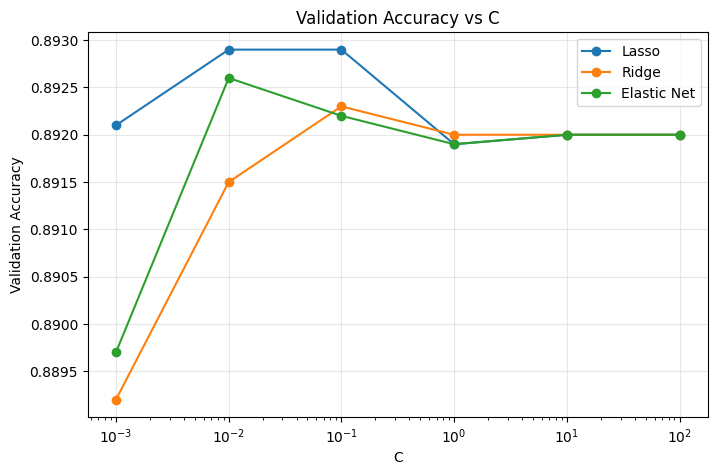

In [6]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    results["C"],
    results["Lasso_val_acc"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results["C"],
    results["Ridge_val_acc"],
    marker="o",
    label="Ridge"
)

plt.semilogx(
    results["C"],
    results["ElasticNet_val_acc"],
    marker="o",
    label="Elastic Net"
)

plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs C")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Step 7 — Plot non-zero coefficients

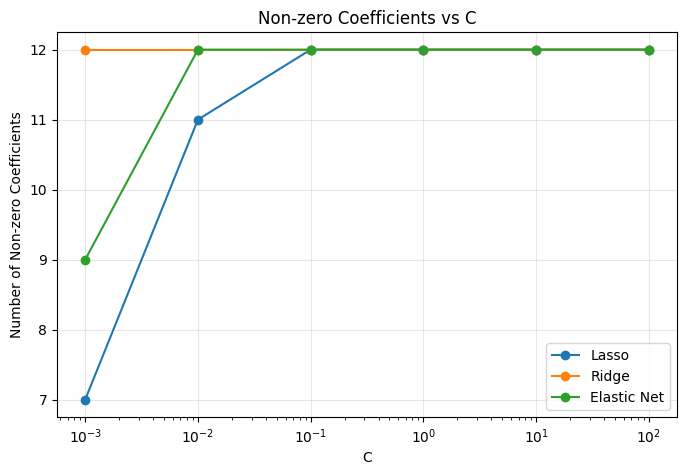

In [7]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    results["C"],
    results["Lasso_nonzero"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results["C"],
    results["Ridge_nonzero"],
    marker="o",
    label="Ridge"
)

plt.semilogx(
    results["C"],
    results["ElasticNet_nonzero"],
    marker="o",
    label="Elastic Net"
)

plt.xlabel("C")
plt.ylabel("Number of Non-zero Coefficients")
plt.title("Non-zero Coefficients vs C")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Step 8 — Generate shrinkage paths

In [8]:
lasso_coefs = []
ridge_coefs = []
elastic_coefs = []

for C in C_values:

    lasso = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=C,
        max_iter=1000
    )

    ridge = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=C,
        max_iter=1000
    )

    elastic = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=C,
        max_iter=2000
    )

    lasso.fit(X_train, y_train)
    ridge.fit(X_train, y_train)
    elastic.fit(X_train, y_train)

    lasso_coefs.append(lasso.coef_[0])
    ridge_coefs.append(ridge.coef_[0])
    elastic_coefs.append(elastic.coef_[0])

Step 9 — Plot the shrinkage paths

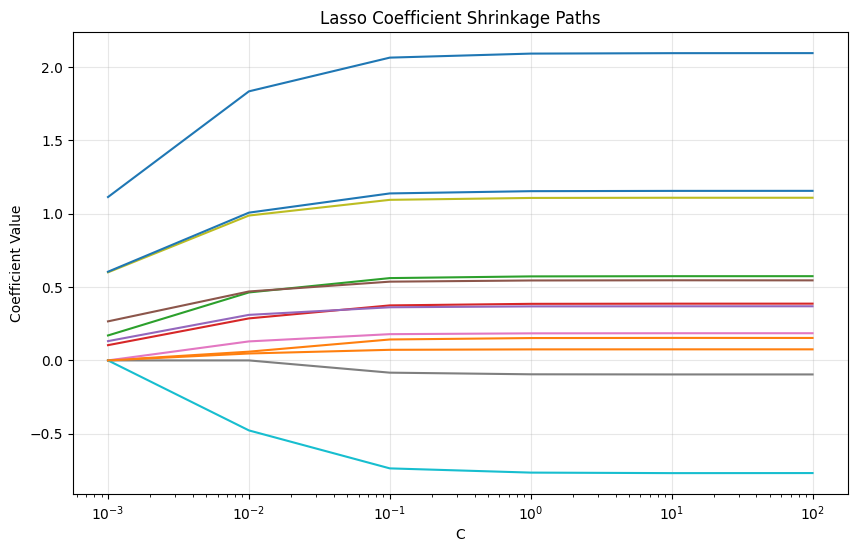

In [9]:
plt.figure(figsize=(10, 6))

plt.semilogx(
    C_values,
    np.array(lasso_coefs)
)

plt.xlabel("C")
plt.ylabel("Coefficient Value")
plt.title("Lasso Coefficient Shrinkage Paths")
plt.grid(alpha=0.3)

plt.show()

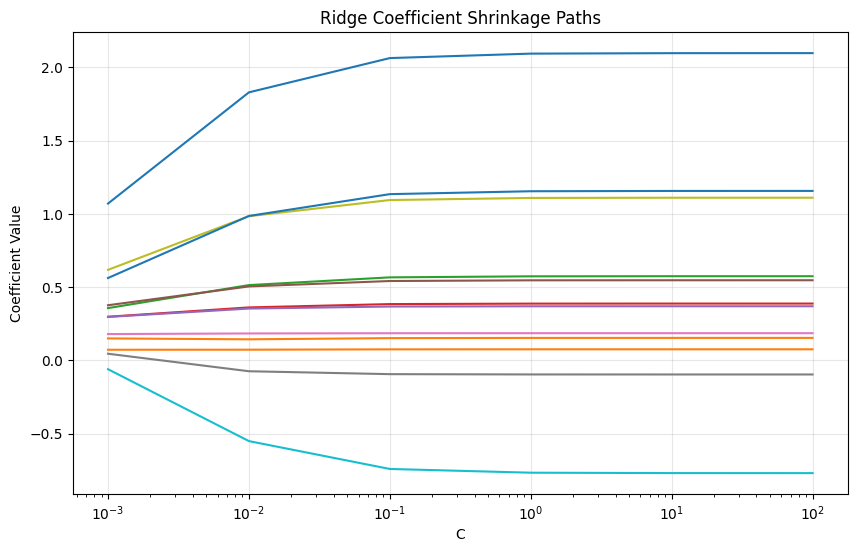

In [10]:
plt.figure(figsize=(10, 6))

plt.semilogx(
    C_values,
    np.array(ridge_coefs)
)

plt.xlabel("C")
plt.ylabel("Coefficient Value")
plt.title("Ridge Coefficient Shrinkage Paths")
plt.grid(alpha=0.3)

plt.show()

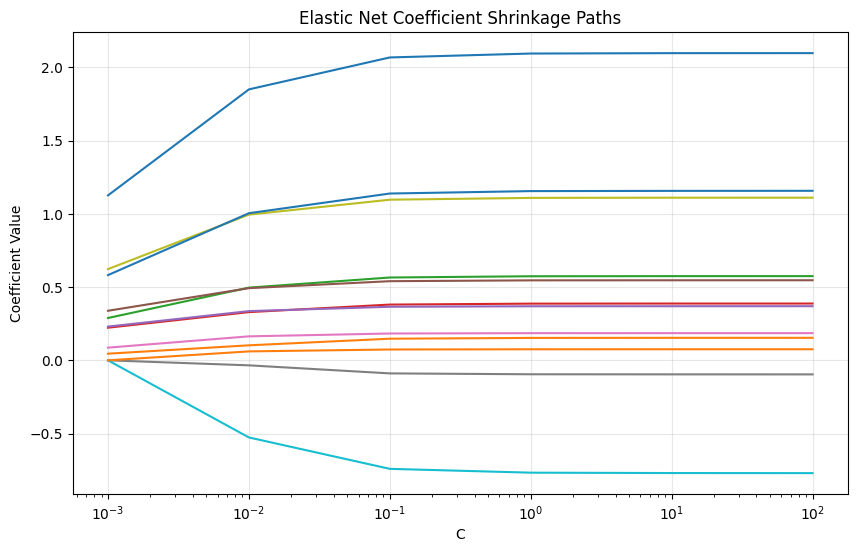

In [11]:
plt.figure(figsize=(10, 6))

plt.semilogx(
    C_values,
    np.array(elastic_coefs)
)

plt.xlabel("C")
plt.ylabel("Coefficient Value")
plt.title("Elastic Net Coefficient Shrinkage Paths")
plt.grid(alpha=0.3)

plt.show()

Step 10 — Final comparison table

In [12]:
print("========== EXPERIMENT 5 RESULTS ==========")

print(results.round(4))

========== EXPERIMENT 5 RESULTS ==========
         C  Lasso_val_acc  Ridge_val_acc  ElasticNet_val_acc  Lasso_nonzero  \
0    0.001         0.8921         0.8892              0.8897              7   
1    0.010         0.8929         0.8915              0.8926             11   
2    0.100         0.8929         0.8923              0.8922             12   
3    1.000         0.8919         0.8920              0.8919             12   
4   10.000         0.8920         0.8920              0.8920             12   
5  100.000         0.8920         0.8920              0.8920             12   

   Ridge_nonzero  ElasticNet_nonzero  
0             12                   9  
1             12                  12  
2             12                  12  
3             12                  12  
4             12                  12  
5             12                  12  
